# Feature Interaction & Correlation Matrix

**Goal:** Identify redundant features to avoid combining signals that measure the same thing.

**Key rule:** If two features have Spearman |corr| > 0.7 → keep only the one with higher IC.

**Features tested (all PREDICTIVE-rated in CATALOG):**
- `ma_spread_on_trend` — ATR-normalised MA spread on HP trend (IC −0.318)
- `trend_deviation_from_ma` — HP trend deviation from its own MA (IC −0.344)
- `ma_crossover_signal` — Binary MA crossover on HP trend (inverted, IC −0.397)
- `hp_trend_level` — HP trend level; mean-reversion (IC −0.397)
- `trend_strength` — Regime: percentile rank of |slope|/ATR (new)
- `vol_zscore` — Vol regime z-score (new)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import FXDataLoader
from src.features import (
    compute_log_returns, atr, causal_hp_trend, hp_trend_slope,
    ma_spread_on_trend, ma_crossover_signal, trend_deviation_from_ma,
    compute_correlation_matrix, find_redundant_pairs, select_non_redundant_features,
    trend_strength, vol_zscore,
    CATALOG,
)

plt.style.use('seaborn-v0_8-darkgrid')
print('Imports OK')

Imports OK


## 1. Load USDJPY H1 data

In [2]:
loader = FXDataLoader('../data/raw')
df = loader.load('USDJPY_10yr_1h_dukascopy')
print(f'Loaded {len(df):,} bars from {df.index[0].date()} to {df.index[-1].date()}')
df.tail(3)

missing_bars: First missing: 2016-03-18 21:00:00+00:00
missing_bars: Last missing: 2026-03-06 23:00:00+00:00
extreme_spikes: Max z-score: 26.26


Loaded 62,303 bars from 2016-03-13 to 2026-03-10


,open,high,low,close,volume
datetime,,,,,
2026-03-10 18:00:00+00:00,157.597,157.981,157.595,157.867,16990.77
2026-03-10 19:00:00+00:00,157.868,158.132,157.845,158.033,10805.33
2026-03-10 20:00:00+00:00,158.033,158.088,157.971,158.041,3538.07


## 2. Compute all features

In [3]:
close = df['close']
high = df['high']
low = df['low']
log_ret = compute_log_returns(close)
atr_s = atr(high, low, close, window=20)

print('Computing causal HP trend (may take ~60s)...')
trend = causal_hp_trend(close, lamb=3.9e9, window=500)
print('Done.')

slope = hp_trend_slope(trend)

features = {
    'ma_spread_on_trend': ma_spread_on_trend(trend, t1=72, t2=240, atr_series=atr_s),
    'trend_deviation_from_ma': trend_deviation_from_ma(trend, window=240, atr_series=atr_s),
    'ma_crossover_signal': ma_crossover_signal(trend, t1=72, t2=240).replace({np.nan: 0.0}),
    'hp_trend_level': trend / atr_s,
    'trend_strength': trend_strength(trend, atr_s),
    'vol_zscore': vol_zscore(log_ret),
}

feature_df = pd.DataFrame(features).dropna()
print(f'Feature matrix: {feature_df.shape[0]:,} valid bars, {feature_df.shape[1]} features')
feature_df.describe().round(3)

Computing causal HP trend (may take ~60s)...
Done.
Feature matrix: 61,565 valid bars, 6 features


,ma_spread_on_trend,trend_deviation_from_ma,ma_crossover_signal,hp_trend_level,trend_strength,vol_zscore
count,61565.000,61565.000,61565.000,61565.000,61565.000,61565.000
mean,0.653,0.986,0.097,820.270,49.192,-0.023
std,4.752,6.570,0.995,355.138,28.911,1.098
min,-35.071,-48.624,-1.000,81.689,0.017,-2.182
25%,-2.404,-3.334,-1.000,566.904,24.058,-0.645
50%,0.592,0.831,1.000,763.394,48.810,-0.259
75%,3.646,5.216,1.000,1011.556,74.008,0.290
max,25.687,37.050,1.000,4570.446,100.000,13.460


## 3. Spearman & Pearson correlation matrices

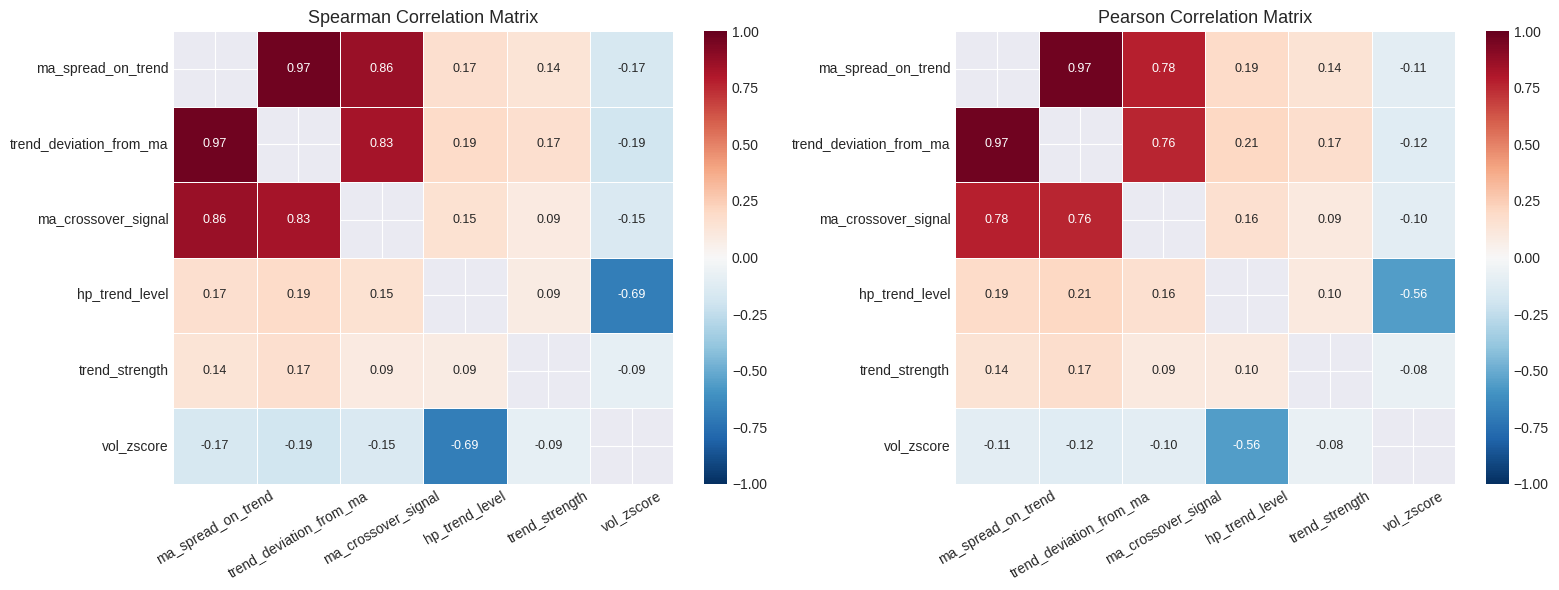

Saved: reports/feature_correlation_matrix.png


In [4]:
spearman_mat, pearson_mat = compute_correlation_matrix(features, method='both')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, mat, title in zip(axes, [spearman_mat, pearson_mat], ['Spearman', 'Pearson']):
    mask = pd.DataFrame(False, index=mat.index, columns=mat.columns)
    for i in range(len(mask)):
        mask.iloc[i, i] = True   # hide diagonal (always 1.0)
    sns.heatmap(
        mat, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
        vmin=-1, vmax=1, linewidths=0.5, mask=mask,
        annot_kws={'size': 9},
    )
    ax.set_title(f'{title} Correlation Matrix', fontsize=13)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/feature_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/feature_correlation_matrix.png')

## 4. Redundant pairs (|corr| > 0.7)

In [5]:
redundant = find_redundant_pairs(spearman_mat, threshold=0.7)

if redundant:
    print(f'Found {len(redundant)} redundant pair(s):')
    for p in redundant:
        print(f'  {p.feature_a} ↔ {p.feature_b}  (|ρ| = {abs(p.correlation):.3f})')
else:
    print('No redundant pairs found at threshold 0.70')

Found 3 redundant pair(s):
  ma_spread_on_trend ↔ trend_deviation_from_ma  (|ρ| = 0.971)
  ma_spread_on_trend ↔ ma_crossover_signal  (|ρ| = 0.862)
  trend_deviation_from_ma ↔ ma_crossover_signal  (|ρ| = 0.835)


## 5. IC scores from CATALOG

In [6]:
# Pull absolute IC from the research catalog for deduplication tiebreaking
ic_mapping = {
    'ma_spread_on_trend':       0.318,
    'trend_deviation_from_ma':  0.344,
    'ma_crossover_signal':      0.397,
    'hp_trend_level':           0.397,
    'trend_strength':           0.0,     # new — no IC yet
    'vol_zscore':               0.0,     # new — no IC yet
}

print('IC scores used for deduplication:')
for k, v in sorted(ic_mapping.items(), key=lambda x: -x[1]):
    print(f'  {k:30s}  |IC| = {v:.3f}')

IC scores used for deduplication:
  ma_crossover_signal             |IC| = 0.397
  hp_trend_level                  |IC| = 0.397
  trend_deviation_from_ma         |IC| = 0.344
  ma_spread_on_trend              |IC| = 0.318
  trend_strength                  |IC| = 0.000
  vol_zscore                      |IC| = 0.000


## 6. Greedy non-redundant feature selection

In [7]:
result = select_non_redundant_features(
    features,
    ic_scores=ic_mapping,
    threshold=0.7,
    method='spearman',
)

print(f'Threshold: |ρ| > {result.threshold}')
print(f'\n✅ KEPT  ({len(result.features_to_keep)}):', result.features_to_keep)
print(f'\n❌ DROPPED ({len(result.features_to_drop)}):', result.features_to_drop)

if result.redundant_pairs:
    print('\nRedundant pair details:')
    for p in result.redundant_pairs:
        print(f'  DROP {p.feature_a:30s}  (corr={p.correlation:+.3f} with {p.keep})')

Threshold: |ρ| > 0.7

✅ KEPT  (4): ['ma_crossover_signal', 'hp_trend_level', 'trend_strength', 'vol_zscore']

❌ DROPPED (2): ['trend_deviation_from_ma', 'ma_spread_on_trend']

Redundant pair details:
  DROP trend_deviation_from_ma         (corr=+0.835 with ma_crossover_signal)
  DROP ma_spread_on_trend              (corr=+0.862 with ma_crossover_signal)


## 7. Summary table

In [8]:
rows = []
for name in features:
    kept = name in result.features_to_keep
    pair = next((p for p in result.redundant_pairs if p.feature_a == name), None)
    rows.append({
        'feature': name,
        'IC': ic_mapping.get(name, np.nan),
        'max_corr_with_kept': spearman_mat.loc[name, result.features_to_keep].abs().drop(name, errors='ignore').max() if kept else abs(pair.correlation) if pair else np.nan,
        'status': '✅ KEEP' if kept else '❌ DROP',
        'redundant_with': pair.keep if pair else '',
    })

summary_df = pd.DataFrame(rows).set_index('feature').sort_values('IC', ascending=False)
summary_df

,IC,max_corr_with_kept,status,redundant_with
feature,,,,
hp_trend_level,0.397,0.691621,✅ KEEP,
ma_crossover_signal,0.397,0.152271,✅ KEEP,
trend_deviation_from_ma,0.344,0.834527,❌ DROP,ma_crossover_signal
ma_spread_on_trend,0.318,0.861959,❌ DROP,ma_crossover_signal
trend_strength,0.000,0.093406,✅ KEEP,
vol_zscore,0.000,0.691621,✅ KEEP,
